In [1]:
# Step 5: Direct Transcriptional-Response Prediction

# Objective: Predict the 128D signature embedding from compound structure & experimental context 

In [2]:
# Locate and inspect the required data

from pathlib import Path

import numpy as np
import pandas as pd



# Find the project root


cwd = Path.cwd()

PROJECT_ROOT = None

for candidate in [cwd, *cwd.parents]:
    if (
        (candidate / "data").exists()
        and (candidate / "models").exists()
    ):
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not locate the project root from: {cwd}"
    )

DATA_DIR = PROJECT_ROOT / "data"

STEP1_EMBED_DIR = DATA_DIR / "step1_embeddings"
STEP2_EMBED_DIR = DATA_DIR / "step2_signature_embeddings"
STEP3_DIR = DATA_DIR / "step3_multimodal"

print("Project root:", PROJECT_ROOT)



# Required files


COMPOUND_EMBEDDING_PATH = (
    STEP1_EMBED_DIR
    / "step1_drug_embeddings_128.npy"
)

SIGNATURE_EMBEDDING_PATH = (
    STEP2_EMBED_DIR
    / "step2_signature_embeddings_latent128_best.npy"
)

MODEL_TABLE_PATH = (
    STEP3_DIR
    / "step3_multimodal_model_table_matched_improved.csv"
)


required_paths = {
    "Compound embeddings": COMPOUND_EMBEDDING_PATH,
    "Signature embeddings": SIGNATURE_EMBEDDING_PATH,
    "Matched model table": MODEL_TABLE_PATH,
}

print("\nRequired files")

for label, path in required_paths.items():
    print(f"{label}: {path.exists()} — {path}")

    assert path.exists(), (
        f"Missing required file: {path}"
    )



# Open embedding arrays


compound_embeddings = np.load(
    COMPOUND_EMBEDDING_PATH,
    mmap_mode="r",
)

signature_embeddings = np.load(
    SIGNATURE_EMBEDDING_PATH,
    mmap_mode="r",
)

print("\nEmbedding arrays")
print(
    "Compound embeddings:",
    compound_embeddings.shape,
    compound_embeddings.dtype,
)

print(
    "Signature embeddings:",
    signature_embeddings.shape,
    signature_embeddings.dtype,
)



# Preview the matched metadata table


model_table_preview = pd.read_csv(
    MODEL_TABLE_PATH,
    nrows=5,
    low_memory=False,
)

print("\nMatched model-table columns")
print(model_table_preview.columns.tolist())

display(model_table_preview)



# Confirm essential index columns

essential_columns = {
    "compound_embedding_row_index",
    "signature_row_index",
}

missing_columns = (
    essential_columns
    - set(model_table_preview.columns)
)

assert not missing_columns, (
    "Missing required columns: "
    f"{sorted(missing_columns)}"
)

print("\nFoundation check complete.")

Project root: /Users/mell/predicting-predictability

Required files
Compound embeddings: True — /Users/mell/predicting-predictability/data/step1_embeddings/step1_drug_embeddings_128.npy
Signature embeddings: True — /Users/mell/predicting-predictability/data/step2_signature_embeddings/step2_signature_embeddings_latent128_best.npy
Matched model table: True — /Users/mell/predicting-predictability/data/step3_multimodal/step3_multimodal_model_table_matched_improved.csv

Embedding arrays
Compound embeddings: (3765890, 128) float32
Signature embeddings: (155722, 128) float32

Matched model-table columns
['signature_row_index', 'compound_embedding_row_index', 'match_method', 'source', 'signature_id', 'base_term', 'signature_compound_query', 'signature_brd_primary', 'compound_name', 'pert_id', 'canonical_smiles', 'inchi_key', 'pubchem_cid', 'moa', 'target', 'parsed_source_prefix', 'parsed_compound', 'parsed_cell_line', 'parsed_time', 'parsed_dose', 'compound_reconstruction_bce', 'compound_bitwi

,signature_row_index,compound_embedding_row_index,match_method,source,signature_id,base_term,signature_compound_query,signature_brd_primary,compound_name,pert_id,...,parsed_time,parsed_dose,compound_reconstruction_bce,compound_bitwise_accuracy,signature_reconstruction_loss,signature_nonzero_mse,signature_zero_mse,signature_nonzero_sign_accuracy,signature_nonzero_gene_count,split
0,0,427,exact_name,L1000,L1000::bortezomib::HT29::::24H::20uM::REP.B007...,bortezomib::HT29::::24H::20uM::REP.B007::C23::...,bortezomib,brd-k50691590,Bortezomib,NaN,...,24H,20uM,0.006478,0.998095,0.267422,0.256192,0.112303,0.949698,497,test
1,2,747,exact_name,L1000,L1000::torin-1::HAP1.CDK4::::24H::3.33uM::MOAR...,torin-1::HAP1.CDK4::::24H::3.33uM::MOAR017::L0...,torin-1,brd-k40175214,1-(4-(4-propionylpiperazin-1-yl)-3-(trifluorom...,BRD-K40175214,...,24H,3.33uM,0.031667,0.989301,0.251352,0.239360,0.119917,0.953629,496,train
2,3,2691,exact_name,L1000,L1000::dequalinium::HAP1.CDK4::::24H::0.66uM::...,dequalinium::HAP1.CDK4::::24H::0.66uM::MOAR017...,dequalinium,brd-k77685957,Dequalinium; dequalinium,BRD-K77685957,...,24H,0.66uM,0.009517,0.997362,0.288659,0.276922,0.117367,0.953252,492,train
3,4,5028,exact_name,L1000,L1000::PD-0325901::HAP1.CDK4::::24H::3.33uM::M...,PD-0325901::HAP1.CDK4::::24H::3.33uM::MOAR017:...,PD-0325901,brd-k49865102,PD-0325901,NaN,...,24H,3.33uM,0.023986,0.992818,0.368139,0.358660,0.094796,0.907445,497,val
4,5,747,exact_name,L1000,L1000::torin-1::HAP1.CDK4::::24H::0.66uM::MOAR...,torin-1::HAP1.CDK4::::24H::0.66uM::MOAR017::L0...,torin-1,brd-k40175214,1-(4-(4-propionylpiperazin-1-yl)-3-(trifluorom...,BRD-K40175214,...,24H,0.66uM,0.031667,0.989301,0.236857,0.223488,0.133690,0.961847,498,train



Foundation check complete.


In [3]:
# Create and inspect the direct-response modeling table

import re
import numpy as np
import pandas as pd



# Load only the columns needed for Step 5


columns_to_load = [
    "signature_row_index",
    "compound_embedding_row_index",
    "signature_id",
    "source",
    "compound_name",
    "parsed_cell_line",
    "parsed_time",
    "parsed_dose",
    "split",
]

model_table = pd.read_csv(
    MODEL_TABLE_PATH,
    usecols=columns_to_load,
    low_memory=False,
)

print("Original matched rows:", len(model_table))
print("Original columns:", model_table.columns.tolist())



# Index

model_table = model_table.dropna(
    subset=[
        "signature_row_index",
        "compound_embedding_row_index",
    ]
).copy()

model_table["signature_row_index"] = (
    model_table["signature_row_index"]
    .astype(int)
)

model_table["compound_embedding_row_index"] = (
    model_table["compound_embedding_row_index"]
    .astype(int)
)

valid_index_mask = (
    model_table["signature_row_index"]
    .between(
        0,
        signature_embeddings.shape[0] - 1,
    )
    &
    model_table["compound_embedding_row_index"]
    .between(
        0,
        compound_embeddings.shape[0] - 1,
    )
)

print(
    "Rows with invalid embedding indices:",
    int((~valid_index_mask).sum()),
)

model_table = (
    model_table.loc[valid_index_mask]
    .reset_index(drop=True)
)


# Convert time values to hours

def parse_time_to_hours(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().upper()
    text = text.replace(" ", "")

    match = re.search(
        r"([-+]?\d*\.?\d+)\s*(MIN|MINS|MINUTE|MINUTES|H|HR|HRS|HOUR|HOURS|D|DAY|DAYS)",
        text,
    )

    if match is None:
        return np.nan

    number = float(match.group(1))
    unit = match.group(2)

    if unit in {"MIN", "MINS", "MINUTE", "MINUTES"}:
        return number / 60.0

    if unit in {"H", "HR", "HRS", "HOUR", "HOURS"}:
        return number

    if unit in {"D", "DAY", "DAYS"}:
        return number * 24.0

    return np.nan


model_table["time_hours"] = (
    model_table["parsed_time"]
    .apply(parse_time_to_hours)
)



# Convert dose values to micromolar


def parse_dose_to_um(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().upper()
    text = (
        text
        .replace("Μ", "U")
        .replace("µ", "U")
        .replace(" ", "")
    )

    match = re.search(
        r"([-+]?\d*\.?\d+)\s*(PM|NM|UM|MM|M)",
        text,
    )

    if match is None:
        return np.nan

    number = float(match.group(1))
    unit = match.group(2)

    conversion_to_um = {
        "PM": 1e-6,
        "NM": 1e-3,
        "UM": 1.0,
        "MM": 1e3,
        "M": 1e6,
    }

    return number * conversion_to_um[unit]


model_table["dose_um"] = (
    model_table["parsed_dose"]
    .apply(parse_dose_to_um)
)



# Standardize category context


for column in [
    "source",
    "compound_name",
    "parsed_cell_line",
]:
    model_table[column] = (
        model_table[column]
        .astype("string")
        .str.strip()
    )

model_table["source"] = (
    model_table["source"]
    .fillna("UNKNOWN")
)

model_table["parsed_cell_line"] = (
    model_table["parsed_cell_line"]
    .fillna("UNKNOWN")
)


# Remove duplicate signature rows, if any


duplicate_signature_count = int(
    model_table["signature_row_index"]
    .duplicated()
    .sum()
)

print(
    "\nDuplicate signature-row indices:",
    duplicate_signature_count,
)

model_table = (
    model_table
    .drop_duplicates(
        subset="signature_row_index",
        keep="first",
    )
    .reset_index(drop=True)
)



# Create a fully context-complete subset

context_complete_mask = (
    model_table["time_hours"].notna()
    &
    model_table["dose_um"].notna()
    &
    model_table["parsed_cell_line"].ne("UNKNOWN")
)

context_complete_table = (
    model_table.loc[context_complete_mask]
    .copy()
    .reset_index(drop=True)
)



# Summarize available data


print("\nClean matched dataset")
print("Rows:", len(model_table))
print(
    "Unique compounds:",
    model_table["compound_embedding_row_index"].nunique(),
)
print(
    "Unique signatures:",
    model_table["signature_row_index"].nunique(),
)

print("\nContext-complete dataset")
print("Rows:", len(context_complete_table))
print(
    "Unique compounds:",
    context_complete_table[
        "compound_embedding_row_index"
    ].nunique(),
)

missing_context = pd.DataFrame(
    {
        "column": [
            "parsed_cell_line",
            "time_hours",
            "dose_um",
        ],
        "missing_rows": [
            int(
                model_table["parsed_cell_line"]
                .eq("UNKNOWN")
                .sum()
            ),
            int(
                model_table["time_hours"]
                .isna()
                .sum()
            ),
            int(
                model_table["dose_um"]
                .isna()
                .sum()
            ),
        ],
    }
)

print("\nMissing context")
display(missing_context)

print("\nRows and compounds by source")
source_summary = (
    context_complete_table
    .groupby("source")
    .agg(
        n_signatures=(
            "signature_row_index",
            "size",
        ),
        n_compounds=(
            "compound_embedding_row_index",
            "nunique",
        ),
        n_cell_lines=(
            "parsed_cell_line",
            "nunique",
        ),
    )
    .sort_values(
        "n_signatures",
        ascending=False,
    )
)

display(source_summary)

print("\nMost common cell lines")
display(
    context_complete_table[
        "parsed_cell_line"
    ]
    .value_counts()
    .head(20)
    .rename_axis("cell_line")
    .reset_index(name="n_signatures")
)

print("\nTreatment-time summary, hours")
display(
    context_complete_table["time_hours"]
    .describe()
    .to_frame()
)

print("\nDose summary, micromolar")
display(
    context_complete_table["dose_um"]
    .describe()
    .to_frame()
)

Original matched rows: 112974
Original columns: ['signature_row_index', 'compound_embedding_row_index', 'source', 'signature_id', 'compound_name', 'parsed_cell_line', 'parsed_time', 'parsed_dose', 'split']
Rows with invalid embedding indices: 0

Duplicate signature-row indices: 0

Clean matched dataset
Rows: 112974
Unique compounds: 6605
Unique signatures: 112974

Context-complete dataset
Rows: 110680
Unique compounds: 6525

Missing context


,column,missing_rows
0,parsed_cell_line,0
1,time_hours,2292
2,dose_um,2294



Rows and compounds by source


,n_signatures,n_compounds,n_cell_lines
source,,,
L1000,60962,4717,163
tahoe-100m,39606,273,49
novartis,4554,1601,1
cmap-build02,3945,841,5
sciplex,1274,105,3
deepcovermoa,339,339,1



Most common cell lines


,cell_line,n_signatures
0,MCF7,9562
1,A549,6926
2,PC3,6866
3,U2OS,4554
4,A375,4395
5,HA1E,4201
6,HT29,3509
7,VCAP,3234
8,HEPG2,2166
9,HELA,2103



Treatment-time summary, hours


,time_hours
count,110680.000000
mean,21.238471
std,7.351580
min,2.000000
25%,24.000000
50%,24.000000
75%,24.000000
max,72.000000



Dose summary, micromolar


,dose_um
count,110680.000000
mean,14.461314
std,1427.939315
min,0.001000
25%,0.500000
50%,5.000000
75%,10.000000
max,320000.000000


In [4]:
# Isolate and inspect the L1000 dataset

import numpy as np
import pandas as pd



# Keep context-complete L1000 observations only


l1000_table = (
    context_complete_table.loc[
        context_complete_table["source"].eq("L1000")
    ]
    .copy()
    .reset_index(drop=True)
)

print("L1000 signatures:", len(l1000_table))

print(
    "L1000 compounds:",
    l1000_table[
        "compound_embedding_row_index"
    ].nunique(),
)

print(
    "L1000 cell lines:",
    l1000_table[
        "parsed_cell_line"
    ].nunique(),
)



# Count signatures available for each compound


signatures_per_compound = (
    l1000_table
    .groupby(
        "compound_embedding_row_index"
    )
    .agg(
        compound_name=(
            "compound_name",
            "first",
        ),
        n_signatures=(
            "signature_row_index",
            "size",
        ),
        n_cell_lines=(
            "parsed_cell_line",
            "nunique",
        ),
        n_times=(
            "time_hours",
            "nunique",
        ),
        n_doses=(
            "dose_um",
            "nunique",
        ),
    )
    .reset_index()
)

print("\nSignatures per compound")
display(
    signatures_per_compound[
        "n_signatures"
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .to_frame()
)



# Inspect treatment times


print("\nMost common L1000 treatment times")

display(
    l1000_table[
        "time_hours"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("time_hours")
    .reset_index(name="n_signatures")
)



# Inspect dose distribution


print("\nL1000 dose summary, micromolar")

display(
    l1000_table[
        "dose_um"
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .to_frame()
)



# Inspect the largest parsed doses


print("\nLargest parsed L1000 doses")

display(
    l1000_table[
        [
            "compound_name",
            "parsed_cell_line",
            "parsed_time",
            "parsed_dose",
            "dose_um",
            "signature_id",
        ]
    ]
    .sort_values(
        "dose_um",
        ascending=False,
    )
    .head(20)
)



# Inspect the most common raw dose labels


print("\nMost common raw L1000 dose labels")

display(
    l1000_table[
        "parsed_dose"
    ]
    .value_counts()
    .head(25)
    .rename_axis("parsed_dose")
    .reset_index(name="n_signatures")
)

L1000 signatures: 60962
L1000 compounds: 4717
L1000 cell lines: 163

Signatures per compound


,n_signatures
count,4717.000000
mean,12.923892
std,71.539976
min,1.000000
10%,1.000000
25%,1.000000
50%,3.000000
75%,8.000000
90%,22.000000
95%,46.000000



Most common L1000 treatment times


,time_hours,n_signatures
0,2.0,41
1,3.0,1082
2,4.0,470
3,6.0,12599
4,12.0,64
5,24.0,45853
6,48.0,820
7,72.0,33



L1000 dose summary, micromolar


,dose_um
count,60962.000000
mean,23.763235
std,1923.564268
min,0.001000
1%,0.030000
5%,0.080000
10%,0.125000
25%,1.110000
50%,10.000000
75%,10.000000



Largest parsed L1000 doses


,compound_name,parsed_cell_line,parsed_time,parsed_dose,dose_um,signature_id
15751,Diatrizoate; diatrizoic-acid,HPTEC,6H,320000uM,320000.0,L1000::diatrizoic-acid::HPTEC::::6H::320000uM:...
21512,Diatrizoate; diatrizoic-acid,HPTEC,24H,320000uM,320000.0,L1000::diatrizoic-acid::HPTEC::::24H::320000uM...
21558,Diatrizoate; diatrizoic-acid,HPTEC,24H,100000uM,100000.0,L1000::diatrizoic-acid::HPTEC::::24H::100000uM...
15733,Diatrizoate; diatrizoic-acid,HPTEC,6H,100000uM,100000.0,L1000::diatrizoic-acid::HPTEC::::6H::100000uM:...
631,CID 6610281; lithium-chloride,NPC.177,24H,10000uM,10000.0,L1000::lithium-chloride::NPC.177::::24H::10000...
20676,CID 6610281; lithium-chloride,NPC.179,24H,10000uM,10000.0,L1000::lithium-chloride::NPC.179::::24H::10000...
24148,CID 6610281; lithium-chloride,NPC.215,24H,10000uM,10000.0,L1000::lithium-chloride::NPC.215::::24H::10000...
21516,Diatrizoate; diatrizoic-acid,HPTEC,24H,10000uM,10000.0,L1000::diatrizoic-acid::HPTEC::::24H::10000uM:...
9137,CID 6610281; lithium-chloride,NPC.170,24H,10000uM,10000.0,L1000::lithium-chloride::NPC.170::::24H::10000...
28027,CID 6610281; lithium-chloride,NPC.8330,24H,10000uM,10000.0,L1000::lithium-chloride::NPC.8330::::24H::1000...



Most common raw L1000 dose labels


,parsed_dose,n_signatures
0,10uM,31199
1,20uM,5104
2,1.11uM,4897
3,3.33uM,4662
4,0.37uM,2573
5,0.04uM,1722
6,0.125uM,1572
7,2.22uM,1391
8,0.12uM,1253
9,0.08uM,850


In [5]:
# Prepare, Create 

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42



# Keep valid positive dose and time values


step5_table = (
    l1000_table.loc[
        (l1000_table["dose_um"] > 0)
        &
        (l1000_table["time_hours"] > 0)
    ]
    .copy()
    .reset_index(drop=True)
)

print("Rows before final filtering:", len(l1000_table))
print("Rows after final filtering:", len(step5_table))



# Transform dose because it spans several orders of magnitude


step5_table["log10_dose_um"] = np.log10(
    step5_table["dose_um"]
)



# Split unique compounds, not individual signatures


unique_compound_ids = (
    step5_table["compound_embedding_row_index"]
    .drop_duplicates()
    .to_numpy(dtype=int)
)

train_compound_ids, temporary_compound_ids = train_test_split(
    unique_compound_ids,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

validation_compound_ids, test_compound_ids = train_test_split(
    temporary_compound_ids,
    test_size=0.50,
    random_state=RANDOM_STATE,
)



# Assign each signature according to its compound


train_compound_set = set(train_compound_ids)
validation_compound_set = set(validation_compound_ids)
test_compound_set = set(test_compound_ids)

step5_table["cold_drug_split"] = "unassigned"

step5_table.loc[
    step5_table["compound_embedding_row_index"].isin(
        train_compound_set
    ),
    "cold_drug_split",
] = "train"

step5_table.loc[
    step5_table["compound_embedding_row_index"].isin(
        validation_compound_set
    ),
    "cold_drug_split",
] = "validation"

step5_table.loc[
    step5_table["compound_embedding_row_index"].isin(
        test_compound_set
    ),
    "cold_drug_split",
] = "test"



# Verify that no compound appears in multiple splits


split_compound_sets = {
    split_name: set(
        step5_table.loc[
            step5_table["cold_drug_split"].eq(split_name),
            "compound_embedding_row_index",
        ]
    )
    for split_name in [
        "train",
        "validation",
        "test",
    ]
}

assert not (
    split_compound_sets["train"]
    & split_compound_sets["validation"]
)

assert not (
    split_compound_sets["train"]
    & split_compound_sets["test"]
)

assert not (
    split_compound_sets["validation"]
    & split_compound_sets["test"]
)

assert step5_table["cold_drug_split"].ne(
    "unassigned"
).all()



# Summarize the resulting split


split_summary = (
    step5_table
    .groupby("cold_drug_split")
    .agg(
        n_signatures=(
            "signature_row_index",
            "size",
        ),
        n_compounds=(
            "compound_embedding_row_index",
            "nunique",
        ),
        n_cell_lines=(
            "parsed_cell_line",
            "nunique",
        ),
        median_signatures_per_compound=(
            "compound_embedding_row_index",
            lambda values: values.value_counts().median(),
        ),
    )
    .reindex(
        [
            "train",
            "validation",
            "test",
        ]
    )
)

print("\nCold-drug split summary")
display(split_summary)


# Inspect the transformed context variables


print("\nTransformed dose summary")
display(
    step5_table["log10_dose_um"]
    .describe()
    .to_frame()
)

print("\nTreatment times by split")
display(
    pd.crosstab(
        step5_table["time_hours"],
        step5_table["cold_drug_split"],
    )
)



# Save the split metadata


STEP5_DIR = (
    DATA_DIR
    / "step5_direct_response"
)

STEP5_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

STEP5_SPLIT_PATH = (
    STEP5_DIR
    / "step5_l1000_cold_drug_split.csv"
)

step5_table.to_csv(
    STEP5_SPLIT_PATH,
    index=False,
)

print("\nSaved cold-drug split:")
print(STEP5_SPLIT_PATH)

Rows before final filtering: 60962
Rows after final filtering: 60962

Cold-drug split summary


,n_signatures,n_compounds,n_cell_lines,median_signatures_per_compound
cold_drug_split,,,,
train,46931,3773,162,3.0
validation,8369,472,135,3.0
test,5662,472,150,3.0



Transformed dose summary


,log10_dose_um
count,60962.000000
mean,0.566822
std,0.764704
min,-3.000000
25%,0.045323
50%,1.000000
75%,1.000000
max,5.505150



Treatment times by split


cold_drug_split,test,train,validation
time_hours,,,
2.0,2,24,15
3.0,85,816,181
4.0,52,281,137
6.0,1265,9761,1573
12.0,9,45,10
24.0,4144,35350,6359
48.0,103,627,90
72.0,2,27,4



Saved cold-drug split:
/Users/mell/predicting-predictability/data/step5_direct_response/step5_l1000_cold_drug_split.csv


In [6]:
# Build model-ready inputs and 128D response targets

import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Separate metadata by cold-drug split

train_table = (
    step5_table.loc[
        step5_table["cold_drug_split"].eq("train")
    ]
    .copy()
    .reset_index(drop=True)
)

validation_table = (
    step5_table.loc[
        step5_table["cold_drug_split"].eq("validation")
    ]
    .copy()
    .reset_index(drop=True)
)

test_table = (
    step5_table.loc[
        step5_table["cold_drug_split"].eq("test")
    ]
    .copy()
    .reset_index(drop=True)
)


# Add a log-transformed treatment-time variable


for table in [
    train_table,
    validation_table,
    test_table,
]:
    table["log2_time_hours"] = np.log2(
        table["time_hours"]
    )


# Cell lines


try:
    cell_line_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
        dtype=np.float32,
    )
except TypeError:
    
    cell_line_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False,
        dtype=np.float32,
    )

train_cell_context = cell_line_encoder.fit_transform(
    train_table[["parsed_cell_line"]]
)

validation_cell_context = cell_line_encoder.transform(
    validation_table[["parsed_cell_line"]]
)

test_cell_context = cell_line_encoder.transform(
    test_table[["parsed_cell_line"]]
)

print(
    "Cell-line categories learned from training:",
    len(cell_line_encoder.categories_[0]),
)



# Standardize


numeric_context_columns = [
    "log10_dose_um",
    "log2_time_hours",
]

context_scaler = StandardScaler()

train_numeric_context = context_scaler.fit_transform(
    train_table[numeric_context_columns]
).astype(np.float32)

validation_numeric_context = context_scaler.transform(
    validation_table[numeric_context_columns]
).astype(np.float32)

test_numeric_context = context_scaler.transform(
    test_table[numeric_context_columns]
).astype(np.float32)



# Retrieve Step 1 compound embeddings


def get_compound_embedding_rows(table):
    row_indices = (
        table["compound_embedding_row_index"]
        .to_numpy(dtype=int)
    )

    return np.asarray(
        compound_embeddings[row_indices],
        dtype=np.float32,
    )


X_train_compound = get_compound_embedding_rows(
    train_table
)

X_validation_compound = get_compound_embedding_rows(
    validation_table
)

X_test_compound = get_compound_embedding_rows(
    test_table
)



# Combine structure and experimental context


X_train = np.concatenate(
    [
        X_train_compound,
        train_cell_context,
        train_numeric_context,
    ],
    axis=1,
).astype(np.float32)

X_validation = np.concatenate(
    [
        X_validation_compound,
        validation_cell_context,
        validation_numeric_context,
    ],
    axis=1,
).astype(np.float32)

X_test = np.concatenate(
    [
        X_test_compound,
        test_cell_context,
        test_numeric_context,
    ],
    axis=1,
).astype(np.float32)



# Retrieve the actual Step 2 response embeddings


def get_signature_embedding_rows(table):
    row_indices = (
        table["signature_row_index"]
        .to_numpy(dtype=int)
    )

    return np.asarray(
        signature_embeddings[row_indices],
        dtype=np.float32,
    )


Y_train = get_signature_embedding_rows(
    train_table
)

Y_validation = get_signature_embedding_rows(
    validation_table
)

Y_test = get_signature_embedding_rows(
    test_table
)



# Confirm shapes and data quality


print("\nModel arrays")

print("X train:", X_train.shape)
print("Y train:", Y_train.shape)

print("X validation:", X_validation.shape)
print("Y validation:", Y_validation.shape)

print("X test:", X_test.shape)
print("Y test:", Y_test.shape)

assert X_train.shape[0] == Y_train.shape[0]
assert X_validation.shape[0] == Y_validation.shape[0]
assert X_test.shape[0] == Y_test.shape[0]

assert Y_train.shape[1] == 128
assert Y_validation.shape[1] == 128
assert Y_test.shape[1] == 128

assert np.isfinite(X_train).all()
assert np.isfinite(X_validation).all()
assert np.isfinite(X_test).all()

assert np.isfinite(Y_train).all()
assert np.isfinite(Y_validation).all()
assert np.isfinite(Y_test).all()

print("\nInput breakdown")
print("Compound embedding features:", 128)
print(
    "Cell-line features:",
    train_cell_context.shape[1],
)
print("Numeric context features:", 2)
print("Total input features:", X_train.shape[1])

print("\nModel-ready arrays created successfully.")

Cell-line categories learned from training: 162

Model arrays
X train: (46931, 292)
Y train: (46931, 128)
X validation: (8369, 292)
Y validation: (8369, 128)
X test: (5662, 292)
Y test: (5662, 128)

Input breakdown
Compound embedding features: 128
Cell-line features: 162
Numeric context features: 2
Total input features: 292

Model-ready arrays created successfully.


In [7]:
# Evaluate simple validation baselines

import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error



# Helper: calculate response-embedding metrics


def evaluate_response_predictions(
    actual,
    predicted,
    model_name,
):
    actual = np.asarray(
        actual,
        dtype=np.float32,
    )

    predicted = np.asarray(
        predicted,
        dtype=np.float32,
    )

    # Error across all signatures and embedding dimensions
    mse = mean_squared_error(
        actual,
        predicted,
    )

    mae = mean_absolute_error(
        actual,
        predicted,
    )

    # Cosine similarity for each signature
    numerator = np.sum(
        actual * predicted,
        axis=1,
    )

    denominator = (
        np.linalg.norm(
            actual,
            axis=1,
        )
        *
        np.linalg.norm(
            predicted,
            axis=1,
        )
    )

    cosine_per_signature = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(
            numerator,
            dtype=float,
        ),
        where=denominator != 0,
    )

    # Pearson correlation across the 128 embedding dimensions
    actual_centered = (
        actual
        - actual.mean(
            axis=1,
            keepdims=True,
        )
    )

    predicted_centered = (
        predicted
        - predicted.mean(
            axis=1,
            keepdims=True,
        )
    )

    pearson_numerator = np.sum(
        actual_centered
        * predicted_centered,
        axis=1,
    )

    pearson_denominator = (
        np.linalg.norm(
            actual_centered,
            axis=1,
        )
        *
        np.linalg.norm(
            predicted_centered,
            axis=1,
        )
    )

    pearson_per_signature = np.divide(
        pearson_numerator,
        pearson_denominator,
        out=np.zeros_like(
            pearson_numerator,
            dtype=float,
        ),
        where=pearson_denominator != 0,
    )

    return {
        "model": model_name,
        "mse": float(mse),
        "mae": float(mae),
        "mean_cosine_similarity": float(
            cosine_per_signature.mean()
        ),
        "median_cosine_similarity": float(
            np.median(cosine_per_signature)
        ),
        "mean_pearson": float(
            pearson_per_signature.mean()
        ),
        "median_pearson": float(
            np.median(pearson_per_signature)
        ),
    }



# Baseline 1: global mean training response


global_mean_response = Y_train.mean(
    axis=0,
)

global_mean_validation_predictions = np.repeat(
    global_mean_response[None, :],
    repeats=len(validation_table),
    axis=0,
)

global_mean_metrics = evaluate_response_predictions(
    actual=Y_validation,
    predicted=global_mean_validation_predictions,
    model_name="Global mean response",
)



# Baseline 2: mean training response for each cell line


train_response_frame = pd.DataFrame(
    Y_train
)

train_response_frame[
    "parsed_cell_line"
] = train_table[
    "parsed_cell_line"
].to_numpy()

cell_line_mean_responses = (
    train_response_frame
    .groupby("parsed_cell_line")
    .mean()
)

cell_line_validation_predictions = np.empty_like(
    Y_validation,
    dtype=np.float32,
)

fallback_count = 0

for row_position, cell_line in enumerate(
    validation_table["parsed_cell_line"]
):

    if cell_line in cell_line_mean_responses.index:

        cell_line_validation_predictions[
            row_position
        ] = (
            cell_line_mean_responses
            .loc[cell_line]
            .to_numpy(dtype=np.float32)
        )

    else:

        cell_line_validation_predictions[
            row_position
        ] = global_mean_response

        fallback_count += 1


cell_line_mean_metrics = evaluate_response_predictions(
    actual=Y_validation,
    predicted=cell_line_validation_predictions,
    model_name="Cell-line mean response",
)



# Compare and save baseline results


baseline_metrics = pd.DataFrame(
    [
        global_mean_metrics,
        cell_line_mean_metrics,
    ]
).sort_values(
    "mse"
).reset_index(drop=True)

print(
    "Validation signatures:",
    len(validation_table),
)

print(
    "Validation rows requiring global-mean fallback:",
    fallback_count,
)

print("\nValidation baseline performance")
display(baseline_metrics)


BASELINE_METRICS_PATH = (
    STEP5_DIR
    / "step5_l1000_validation_baseline_metrics.csv"
)

baseline_metrics.to_csv(
    BASELINE_METRICS_PATH,
    index=False,
)

print("\nSaved baseline metrics:")
print(BASELINE_METRICS_PATH)

Validation signatures: 8369
Validation rows requiring global-mean fallback: 0

Validation baseline performance


,model,mse,mae,mean_cosine_similarity,median_cosine_similarity,mean_pearson,median_pearson
0,Global mean response,0.775933,0.702002,0.592494,0.594895,0.593036,0.595078
1,Cell-line mean response,0.781761,0.704485,0.588684,0.592605,0.589213,0.592384



Saved baseline metrics:
/Users/mell/predicting-predictability/data/step5_direct_response/step5_l1000_validation_baseline_metrics.csv


In [8]:
# Train and evaluate Ridge regression

import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler



# Standardize the 128 compound-embedding features

compound_feature_scaler = StandardScaler()

X_train_compound_scaled = (
    compound_feature_scaler
    .fit_transform(X_train_compound)
    .astype(np.float32)
)

X_validation_compound_scaled = (
    compound_feature_scaler
    .transform(X_validation_compound)
    .astype(np.float32)
)

X_test_compound_scaled = (
    compound_feature_scaler
    .transform(X_test_compound)
    .astype(np.float32)
)



# Rebuild inputs 


X_train_ridge = np.concatenate(
    [
        X_train_compound_scaled,
        train_cell_context,
        train_numeric_context,
    ],
    axis=1,
).astype(np.float32)

X_validation_ridge = np.concatenate(
    [
        X_validation_compound_scaled,
        validation_cell_context,
        validation_numeric_context,
    ],
    axis=1,
).astype(np.float32)

X_test_ridge = np.concatenate(
    [
        X_test_compound_scaled,
        test_cell_context,
        test_numeric_context,
    ],
    axis=1,
).astype(np.float32)

print("Ridge training input:", X_train_ridge.shape)
print("Ridge validation input:", X_validation_ridge.shape)



# Test 

ridge_alphas = [
    0.1,
    1.0,
    10.0,
    100.0,
    1000.0,
]

ridge_models = {}
ridge_validation_predictions = {}
ridge_results = []

for alpha in ridge_alphas:

    print(f"Training Ridge with alpha={alpha}...")

    ridge_model = Ridge(
        alpha=alpha,
        random_state=42,
    )

    ridge_model.fit(
        X_train_ridge,
        Y_train,
    )

    validation_predictions = ridge_model.predict(
        X_validation_ridge
    ).astype(np.float32)

    metrics = evaluate_response_predictions(
        actual=Y_validation,
        predicted=validation_predictions,
        model_name=f"Ridge alpha={alpha}",
    )

    metrics["alpha"] = alpha

    ridge_results.append(metrics)
    ridge_models[alpha] = ridge_model
    ridge_validation_predictions[alpha] = (
        validation_predictions
    )



# Select the model with the lowest validation MSE


ridge_validation_metrics = (
    pd.DataFrame(ridge_results)
    .sort_values("mse")
    .reset_index(drop=True)
)

best_ridge_alpha = float(
    ridge_validation_metrics.iloc[0]["alpha"]
)

best_ridge_model = ridge_models[
    best_ridge_alpha
]

best_ridge_validation_predictions = (
    ridge_validation_predictions[
        best_ridge_alpha
    ]
)

print("\nRidge validation performance")
display(ridge_validation_metrics)

print(
    "\nBest Ridge alpha:",
    best_ridge_alpha,
)



# Compare best Ridge with the global mean baseline


best_ridge_mse = float(
    ridge_validation_metrics.iloc[0]["mse"]
)

global_baseline_mse = float(
    baseline_metrics.loc[
        baseline_metrics["model"].eq(
            "Global mean response"
        ),
        "mse",
    ].iloc[0]
)

mse_improvement_percent = (
    (
        global_baseline_mse
        - best_ridge_mse
    )
    / global_baseline_mse
    * 100
)

print(
    "MSE improvement over global mean:",
    f"{mse_improvement_percent:.2f}%",
)



# Save validation results


RIDGE_METRICS_PATH = (
    STEP5_DIR
    / "step5_l1000_validation_ridge_metrics.csv"
)

ridge_validation_metrics.to_csv(
    RIDGE_METRICS_PATH,
    index=False,
)

print("\nSaved Ridge metrics:")
print(RIDGE_METRICS_PATH)

Ridge training input: (46931, 292)
Ridge validation input: (8369, 292)
Training Ridge with alpha=0.1...
Training Ridge with alpha=1.0...
Training Ridge with alpha=10.0...
Training Ridge with alpha=100.0...


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.766453873931823e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Training Ridge with alpha=1000.0...

Ridge validation performance


,model,mse,mae,mean_cosine_similarity,median_cosine_similarity,mean_pearson,median_pearson,alpha
0,Ridge alpha=1000.0,0.761709,0.694880,0.603475,0.605942,0.604418,0.606204,1000.0
1,Ridge alpha=100.0,0.764364,0.696035,0.601783,0.604587,0.602737,0.604894,100.0
2,Ridge alpha=10.0,0.767282,0.697334,0.599940,0.603105,0.600897,0.603792,10.0
3,Ridge alpha=1.0,0.768765,0.697987,0.599050,0.602521,0.600006,0.603166,1.0
4,Ridge alpha=0.1,0.769090,0.698128,0.598863,0.602259,0.599819,0.603096,0.1



Best Ridge alpha: 1000.0
MSE improvement over global mean: 1.83%

Saved Ridge metrics:
/Users/mell/predicting-predictability/data/step5_direct_response/step5_l1000_validation_ridge_metrics.csv


In [9]:
# Train a small MLP 

import copy
import random
import joblib
import numpy as np
import pandas as pd
import torch

from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler



# Reproducibility and device


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)



# Standardize 

target_scaler = StandardScaler()

Y_train_scaled = (
    target_scaler
    .fit_transform(Y_train)
    .astype(np.float32)
)

Y_validation_scaled = (
    target_scaler
    .transform(Y_validation)
    .astype(np.float32)
)



# Convert arrays

train_dataset = TensorDataset(
    torch.from_numpy(X_train_ridge),
    torch.from_numpy(Y_train_scaled),
)

validation_dataset = TensorDataset(
    torch.from_numpy(X_validation_ridge),
    torch.from_numpy(Y_validation_scaled),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=0,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=1024,
    shuffle=False,
    num_workers=0,
)



# Define 


class ResponseMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim=128,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.10),

            nn.Linear(256, output_dim),
        )

    def forward(self, x):
        return self.network(x)


mlp_model = ResponseMLP(
    input_dim=X_train_ridge.shape[1],
    output_dim=128,
).to(device)

loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

print(mlp_model)



# Train 

MAX_EPOCHS = 50
PATIENCE = 8

best_validation_loss = np.inf
best_epoch = 0
best_model_state = None
epochs_without_improvement = 0

training_history = []

for epoch in range(1, MAX_EPOCHS + 1):

    # Training
    mlp_model.train()

    total_training_loss = 0.0
    total_training_rows = 0

    for batch_X, batch_Y in train_loader:

        batch_X = batch_X.to(device)
        batch_Y = batch_Y.to(device)

        optimizer.zero_grad()

        predictions = mlp_model(batch_X)

        loss = loss_function(
            predictions,
            batch_Y,
        )

        loss.backward()
        optimizer.step()

        batch_size = batch_X.shape[0]

        total_training_loss += (
            loss.item() * batch_size
        )

        total_training_rows += batch_size

    mean_training_loss = (
        total_training_loss
        / total_training_rows
    )

    # Validation
    mlp_model.eval()

    total_validation_loss = 0.0
    total_validation_rows = 0

    with torch.no_grad():

        for batch_X, batch_Y in validation_loader:

            batch_X = batch_X.to(device)
            batch_Y = batch_Y.to(device)

            predictions = mlp_model(batch_X)

            loss = loss_function(
                predictions,
                batch_Y,
            )

            batch_size = batch_X.shape[0]

            total_validation_loss += (
                loss.item() * batch_size
            )

            total_validation_rows += batch_size

    mean_validation_loss = (
        total_validation_loss
        / total_validation_rows
    )

    training_history.append(
        {
            "epoch": epoch,
            "training_mse_scaled": mean_training_loss,
            "validation_mse_scaled": mean_validation_loss,
        }
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train={mean_training_loss:.4f} | "
        f"validation={mean_validation_loss:.4f}"
    )

    # Save best validation model
    if mean_validation_loss < best_validation_loss:

        best_validation_loss = mean_validation_loss
        best_epoch = epoch

        best_model_state = copy.deepcopy(
            mlp_model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping after epoch {epoch}."
        )
        break



# Restore the best model


mlp_model.load_state_dict(
    best_model_state
)

print("\nBest epoch:", best_epoch)



# Predict validation responses


mlp_model.eval()

validation_prediction_batches = []

with torch.no_grad():

    for batch_X, _ in validation_loader:

        batch_X = batch_X.to(device)

        batch_predictions = (
            mlp_model(batch_X)
            .cpu()
            .numpy()
        )

        validation_prediction_batches.append(
            batch_predictions
        )

mlp_validation_predictions_scaled = np.concatenate(
    validation_prediction_batches,
    axis=0,
)

mlp_validation_predictions = (
    target_scaler
    .inverse_transform(
        mlp_validation_predictions_scaled
    )
    .astype(np.float32)
)



# Evaluate 


mlp_validation_metrics = (
    evaluate_response_predictions(
        actual=Y_validation,
        predicted=mlp_validation_predictions,
        model_name="MLP",
    )
)

mlp_validation_metrics["best_epoch"] = best_epoch

mlp_validation_metrics_table = pd.DataFrame(
    [mlp_validation_metrics]
)

print("\nMLP validation performance")
display(mlp_validation_metrics_table)



# Compare all validation models


best_ridge_row = (
    ridge_validation_metrics
    .iloc[[0]]
    .copy()
)

comparison_table = pd.concat(
    [
        baseline_metrics,
        best_ridge_row,
        mlp_validation_metrics_table,
    ],
    ignore_index=True,
    sort=False,
).sort_values(
    "mse"
).reset_index(drop=True)

print("\nValidation model comparison")
display(comparison_table)



# Save 

STEP5_MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "step5_direct_response"
)

STEP5_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MLP_MODEL_PATH = (
    STEP5_MODEL_DIR
    / "step5_l1000_mlp_validation_best.pt"
)

TARGET_SCALER_PATH = (
    STEP5_MODEL_DIR
    / "step5_l1000_target_scaler.joblib"
)

MLP_HISTORY_PATH = (
    STEP5_DIR
    / "step5_l1000_mlp_training_history.csv"
)

MLP_METRICS_PATH = (
    STEP5_DIR
    / "step5_l1000_validation_mlp_metrics.csv"
)

torch.save(
    {
        "model_state_dict": best_model_state,
        "input_dim": X_train_ridge.shape[1],
        "output_dim": 128,
        "best_epoch": best_epoch,
    },
    MLP_MODEL_PATH,
)

joblib.dump(
    target_scaler,
    TARGET_SCALER_PATH,
)

pd.DataFrame(
    training_history
).to_csv(
    MLP_HISTORY_PATH,
    index=False,
)

mlp_validation_metrics_table.to_csv(
    MLP_METRICS_PATH,
    index=False,
)

print("\nSaved MLP model:")
print(MLP_MODEL_PATH)

print("\nSaved validation metrics:")
print(MLP_METRICS_PATH)

Device: mps
ResponseMLP(
  (network): Sequential(
    (0): Linear(in_features=292, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
  )
)
Epoch 01 | train=0.9522 | validation=0.9641
Epoch 02 | train=0.9136 | validation=0.9618
Epoch 03 | train=0.9012 | validation=0.9534
Epoch 04 | train=0.8932 | validation=0.9566
Epoch 05 | train=0.8873 | validation=0.9563
Epoch 06 | train=0.8831 | validation=0.9570
Epoch 07 | train=0.8791 | validation=0.9574
Epoch 08 | train=0.8759 | validation=0.9581
Epoch 09 | train=0.8731 | validation=0.9616
Epoch 10 | train=0.8708 | validation=0.9571
Epoch 11 | train=0.8685 | validation=0.9597

Early stopping after epoch 11.

Best epoch: 3

MLP validation performance


,model,mse,mae,mean_cosine_similarity,median_cosine_similarity,mean_pearson,median_pearson,best_epoch
0,MLP,0.739186,0.684397,0.618406,0.61865,0.618876,0.618944,3



Validation model comparison


,model,mse,mae,mean_cosine_similarity,median_cosine_similarity,mean_pearson,median_pearson,alpha,best_epoch
0,MLP,0.739186,0.684397,0.618406,0.618650,0.618876,0.618944,NaN,3.0
1,Ridge alpha=1000.0,0.761709,0.694880,0.603475,0.605942,0.604418,0.606204,1000.0,NaN
2,Global mean response,0.775933,0.702002,0.592494,0.594895,0.593036,0.595078,NaN,NaN
3,Cell-line mean response,0.781761,0.704485,0.588684,0.592605,0.589213,0.592384,NaN,NaN



Saved MLP model:
/Users/mell/predicting-predictability/models/step5_direct_response/step5_l1000_mlp_validation_best.pt

Saved validation metrics:
/Users/mell/predicting-predictability/data/step5_direct_response/step5_l1000_validation_mlp_metrics.csv


In [10]:
# Evaluate selected models on the untouched test set

import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader, TensorDataset



# Global-mean test predictions


global_mean_test_predictions = np.repeat(
    global_mean_response[None, :],
    repeats=len(test_table),
    axis=0,
).astype(np.float32)



# Cell-line-mean test predictions


cell_line_test_predictions = np.empty_like(
    Y_test,
    dtype=np.float32,
)

test_fallback_count = 0

for row_position, cell_line in enumerate(
    test_table["parsed_cell_line"]
):

    if cell_line in cell_line_mean_responses.index:

        cell_line_test_predictions[
            row_position
        ] = (
            cell_line_mean_responses
            .loc[cell_line]
            .to_numpy(dtype=np.float32)
        )

    else:

        cell_line_test_predictions[
            row_position
        ] = global_mean_response

        test_fallback_count += 1



# Best Ridge test predictions


ridge_test_predictions = (
    best_ridge_model
    .predict(X_test_ridge)
    .astype(np.float32)
)



# Best MLP test predictions


Y_test_scaled = (
    target_scaler
    .transform(Y_test)
    .astype(np.float32)
)

test_dataset = TensorDataset(
    torch.from_numpy(X_test_ridge),
    torch.from_numpy(Y_test_scaled),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024,
    shuffle=False,
    num_workers=0,
)

mlp_model.eval()

test_prediction_batches = []

with torch.no_grad():

    for batch_X, _ in test_loader:

        batch_X = batch_X.to(device)

        batch_predictions = (
            mlp_model(batch_X)
            .cpu()
            .numpy()
        )

        test_prediction_batches.append(
            batch_predictions
        )

mlp_test_predictions_scaled = np.concatenate(
    test_prediction_batches,
    axis=0,
)

mlp_test_predictions = (
    target_scaler
    .inverse_transform(
        mlp_test_predictions_scaled
    )
    .astype(np.float32)
)



# Compare final test performance


test_model_metrics = pd.DataFrame(
    [
        evaluate_response_predictions(
            Y_test,
            global_mean_test_predictions,
            "Global mean response",
        ),

        evaluate_response_predictions(
            Y_test,
            cell_line_test_predictions,
            "Cell-line mean response",
        ),

        evaluate_response_predictions(
            Y_test,
            ridge_test_predictions,
            f"Ridge alpha={best_ridge_alpha}",
        ),

        evaluate_response_predictions(
            Y_test,
            mlp_test_predictions,
            "MLP",
        ),
    ]
).sort_values(
    "mse"
).reset_index(drop=True)

print("Cold-drug test signatures:", len(test_table))
print(
    "Cell-line baseline fallback rows:",
    test_fallback_count,
)

print("\nFinal cold-drug test performance")
display(test_model_metrics)



# Calculate one set of MLP metrics per signature


signature_squared_error = np.mean(
    (
        Y_test
        - mlp_test_predictions
    ) ** 2,
    axis=1,
)

signature_absolute_error = np.mean(
    np.abs(
        Y_test
        - mlp_test_predictions
    ),
    axis=1,
)

cosine_numerator = np.sum(
    Y_test
    * mlp_test_predictions,
    axis=1,
)

cosine_denominator = (
    np.linalg.norm(
        Y_test,
        axis=1,
    )
    *
    np.linalg.norm(
        mlp_test_predictions,
        axis=1,
    )
)

signature_cosine = np.divide(
    cosine_numerator,
    cosine_denominator,
    out=np.zeros_like(
        cosine_numerator,
        dtype=float,
    ),
    where=cosine_denominator != 0,
)

actual_centered = (
    Y_test
    - Y_test.mean(
        axis=1,
        keepdims=True,
    )
)

predicted_centered = (
    mlp_test_predictions
    - mlp_test_predictions.mean(
        axis=1,
        keepdims=True,
    )
)

pearson_numerator = np.sum(
    actual_centered
    * predicted_centered,
    axis=1,
)

pearson_denominator = (
    np.linalg.norm(
        actual_centered,
        axis=1,
    )
    *
    np.linalg.norm(
        predicted_centered,
        axis=1,
    )
)

signature_pearson = np.divide(
    pearson_numerator,
    pearson_denominator,
    out=np.zeros_like(
        pearson_numerator,
        dtype=float,
    ),
    where=pearson_denominator != 0,
)



# Attach errors to test metadata


test_signature_results = (
    test_table
    .reset_index(drop=True)
    .copy()
)

test_signature_results[
    "response_embedding_mse"
] = signature_squared_error

test_signature_results[
    "response_embedding_mae"
] = signature_absolute_error

test_signature_results[
    "response_embedding_cosine"
] = signature_cosine

test_signature_results[
    "response_embedding_pearson"
] = signature_pearson



# Save test outputs


TEST_METRICS_PATH = (
    STEP5_DIR
    / "step5_l1000_cold_drug_test_model_metrics.csv"
)

TEST_SIGNATURE_RESULTS_PATH = (
    STEP5_DIR
    / "step5_l1000_cold_drug_test_signature_results.csv"
)

TEST_PREDICTIONS_PATH = (
    STEP5_DIR
    / "step5_l1000_cold_drug_test_mlp_predictions.npy"
)

test_model_metrics.to_csv(
    TEST_METRICS_PATH,
    index=False,
)

test_signature_results.to_csv(
    TEST_SIGNATURE_RESULTS_PATH,
    index=False,
)

np.save(
    TEST_PREDICTIONS_PATH,
    mlp_test_predictions,
)

print("\nSaved final test metrics:")
print(TEST_METRICS_PATH)

print("\nSaved test signature results:")
print(TEST_SIGNATURE_RESULTS_PATH)

print("\nSaved predicted response embeddings:")
print(TEST_PREDICTIONS_PATH)

display(
    test_signature_results[
        [
            "compound_name",
            "parsed_cell_line",
            "time_hours",
            "dose_um",
            "response_embedding_mse",
            "response_embedding_cosine",
            "response_embedding_pearson",
        ]
    ]
    .head()
)

Cold-drug test signatures: 5662
Cell-line baseline fallback rows: 1

Final cold-drug test performance


,model,mse,mae,mean_cosine_similarity,median_cosine_similarity,mean_pearson,median_pearson
0,MLP,0.744348,0.686325,0.631390,0.629693,0.631214,0.629637
1,Ridge alpha=1000.0,0.772455,0.699474,0.613551,0.614285,0.613372,0.614184
2,Global mean response,0.782897,0.704160,0.606226,0.608234,0.606092,0.607988
3,Cell-line mean response,0.786160,0.705479,0.604244,0.607391,0.604108,0.607490



Saved final test metrics:
/Users/mell/predicting-predictability/data/step5_direct_response/step5_l1000_cold_drug_test_model_metrics.csv

Saved test signature results:
/Users/mell/predicting-predictability/data/step5_direct_response/step5_l1000_cold_drug_test_signature_results.csv

Saved predicted response embeddings:
/Users/mell/predicting-predictability/data/step5_direct_response/step5_l1000_cold_drug_test_mlp_predictions.npy


,compound_name,parsed_cell_line,time_hours,dose_um,response_embedding_mse,response_embedding_cosine,response_embedding_pearson
0,BRD-K54606188; JQ1 compound,HT29,24.0,10.00,0.564247,0.686393,0.682190
1,BRD-K54606188; JQ1 compound,HT29,24.0,0.37,0.704928,0.613377,0.605068
2,"(2S)-2-[(4S,5S)-4-methyl-8-(4-methylphenyl)-5-...",HT29,24.0,10.00,0.730950,0.649041,0.647562
3,BRD-K54606188; JQ1 compound,HT29,24.0,1.11,0.651514,0.626825,0.618435
4,BRD-K54606188; JQ1 compound,HT29,24.0,0.04,0.574456,0.564632,0.555215


In [11]:
# Prediction Performance 

import numpy as np
import pandas as pd

from scipy.stats import spearmanr



# Aggregate all held-out signatures belonging to each compound


direct_compound_scores = (
    test_signature_results
    .groupby(
        "compound_embedding_row_index"
    )
    .agg(
        compound_name=(
            "compound_name",
            "first",
        ),
        n_test_signatures=(
            "signature_row_index",
            "size",
        ),
        n_test_cell_lines=(
            "parsed_cell_line",
            "nunique",
        ),
        mean_response_mse=(
            "response_embedding_mse",
            "mean",
        ),
        median_response_mse=(
            "response_embedding_mse",
            "median",
        ),
        mean_response_mae=(
            "response_embedding_mae",
            "mean",
        ),
        mean_response_cosine=(
            "response_embedding_cosine",
            "mean",
        ),
        mean_response_pearson=(
            "response_embedding_pearson",
            "mean",
        ),
    )
    .reset_index()
)

print(
    "Held-out compounds with direct scores:",
    len(direct_compound_scores),
)

print("\nNumber of test signatures per compound")
display(
    direct_compound_scores[
        "n_test_signatures"
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
        ]
    )
    .to_frame()
)



# Load the old Step 3 compound-level predictability score


STEP3_SCORE_PATH = (
    STEP3_DIR
    / "step3_compound_predictability_latent256_final_scores.csv"
)

assert STEP3_SCORE_PATH.exists(), (
    f"Missing Step 3 score file: {STEP3_SCORE_PATH}"
)

step3_scores = pd.read_csv(
    STEP3_SCORE_PATH,
    low_memory=False,
)

required_step3_columns = [
    "compound_embedding_row_index",
    "source_normalized_inverted_score",
    "n_profiles",
]

missing_step3_columns = [
    column
    for column in required_step3_columns
    if column not in step3_scores.columns
]

assert not missing_step3_columns, (
    f"Missing Step 3 columns: {missing_step3_columns}"
)

step3_scores = (
    step3_scores[
        required_step3_columns
    ]
    .dropna()
    .copy()
)

step3_scores[
    "compound_embedding_row_index"
] = (
    step3_scores[
        "compound_embedding_row_index"
    ]
    .astype(int)
)



# Join direct Step 5 results to old Step 3 results


score_comparison = (
    direct_compound_scores
    .merge(
        step3_scores,
        on="compound_embedding_row_index",
        how="inner",
        validate="one_to_one",
    )
)

print(
    "\nCompounds with both Step 3 and Step 5 scores:",
    len(score_comparison),
)



# Compare the two definitions of predictability
#
# Step 3:
# higher score = more predictable
#
# Step 5:
# lower MSE = more predictable
# higher cosine/Pearson = more predictable


comparison_metrics = [
    "mean_response_mse",
    "mean_response_mae",
    "mean_response_cosine",
    "mean_response_pearson",
]

correlation_results = []

for direct_metric in comparison_metrics:

    correlation = spearmanr(
        score_comparison[
            "source_normalized_inverted_score"
        ],
        score_comparison[direct_metric],
    ).correlation

    correlation_results.append(
        {
            "step5_direct_metric": direct_metric,
            "spearman_with_step3_score": correlation,
            "n_compounds": len(score_comparison),
        }
    )

correlation_table = pd.DataFrame(
    correlation_results
)

print("\nRelationship between Step 3 and direct Step 5 performance")
display(correlation_table)



# Save compound-level results


DIRECT_COMPOUND_SCORE_PATH = (
    STEP5_DIR
    / "step5_l1000_cold_drug_direct_compound_scores.csv"
)

STEP3_STEP5_COMPARISON_PATH = (
    STEP5_DIR
    / "step5_l1000_step3_vs_direct_score_comparison.csv"
)

STEP3_STEP5_CORRELATION_PATH = (
    STEP5_DIR
    / "step5_l1000_step3_vs_direct_score_correlations.csv"
)

direct_compound_scores.to_csv(
    DIRECT_COMPOUND_SCORE_PATH,
    index=False,
)

score_comparison.to_csv(
    STEP3_STEP5_COMPARISON_PATH,
    index=False,
)

correlation_table.to_csv(
    STEP3_STEP5_CORRELATION_PATH,
    index=False,
)

print("\nSaved direct compound scores:")
print(DIRECT_COMPOUND_SCORE_PATH)

print("\nSaved Step 3 versus Step 5 comparison:")
print(STEP3_STEP5_COMPARISON_PATH)

print("\nSaved correlations:")
print(STEP3_STEP5_CORRELATION_PATH)

display(
    score_comparison[
        [
            "compound_name",
            "n_test_signatures",
            "mean_response_mse",
            "mean_response_cosine",
            "source_normalized_inverted_score",
            "n_profiles",
        ]
    ]
    .sort_values(
        "mean_response_mse"
    )
    .head(10)
)

Held-out compounds with direct scores: 472

Number of test signatures per compound


,n_test_signatures
count,472.000000
mean,11.995763
std,39.982799
min,1.000000
25%,1.000000
50%,3.000000
75%,8.000000
90%,21.800000
95%,43.900000
max,651.000000



Compounds with both Step 3 and Step 5 scores: 472

Relationship between Step 3 and direct Step 5 performance


,step5_direct_metric,spearman_with_step3_score,n_compounds
0,mean_response_mse,-0.223300,472
1,mean_response_mae,-0.211793,472
2,mean_response_cosine,0.140186,472
3,mean_response_pearson,0.138549,472



Saved direct compound scores:
/Users/mell/predicting-predictability/data/step5_direct_response/step5_l1000_cold_drug_direct_compound_scores.csv

Saved Step 3 versus Step 5 comparison:
/Users/mell/predicting-predictability/data/step5_direct_response/step5_l1000_step3_vs_direct_score_comparison.csv

Saved correlations:
/Users/mell/predicting-predictability/data/step5_direct_response/step5_l1000_step3_vs_direct_score_correlations.csv


,compound_name,n_test_signatures,mean_response_mse,mean_response_cosine,source_normalized_inverted_score,n_profiles
301,2-[[[2-[[(4-Methoxyphenyl)-oxomethyl]amino]phe...,1,0.457808,0.638384,0.417021,1
84,Esmolol; esmolol,1,0.471665,0.595582,0.870692,2
394,4-[(1-Methyl-5-tetrazolyl)thio]-5-(4-nitrophen...,11,0.502111,0.714807,0.917181,11
393,"4-[4-[(1-Methyl-5-tetrazolyl)thio]-5-thieno[2,...",11,0.502456,0.719057,0.988908,11
243,ML228 Analog; VU-0418939-2,15,0.519929,0.723758,0.820564,15
365,4-methyl-N-(2-phenylphenyl)-3-(phenylsulfamoyl...,1,0.528352,0.596663,0.627917,1
210,Digoxigenin; digoxigenin,7,0.553885,0.714368,0.887563,12
116,"2-Chloro-3-methyl-4-((7R,7aS)-tetrahydro-7-hyd...",2,0.559899,0.606041,0.003266,2
271,5-Chloro-7-[(4-ethoxyphenyl)-(3-pyridinylamino...,3,0.565125,0.664017,0.783008,3
395,5-(3-Methylsulfonylphenyl)-4-[(1-methyl-5-tetr...,11,0.567347,0.709162,0.919453,11


In [12]:
# Test whether the Step 3/Step 5 relationship becomes
# clearer for compounds with more held-out signatures

import numpy as np
import pandas as pd

from scipy.stats import spearmanr



# Minimum numbers of held-out signatures to test


minimum_signature_thresholds = [
    1,
    2,
    3,
    5,
    10,
    20,
    50,
]



# Recalculate correlations at each threshold


threshold_results = []

for minimum_signatures in minimum_signature_thresholds:

    subset = score_comparison.loc[
        score_comparison["n_test_signatures"]
        >= minimum_signatures
    ].copy()

    if len(subset) < 10:
        continue

    mse_result = spearmanr(
        subset["source_normalized_inverted_score"],
        subset["mean_response_mse"],
    )

    cosine_result = spearmanr(
        subset["source_normalized_inverted_score"],
        subset["mean_response_cosine"],
    )

    pearson_result = spearmanr(
        subset["source_normalized_inverted_score"],
        subset["mean_response_pearson"],
    )

    threshold_results.append(
        {
            "minimum_test_signatures": minimum_signatures,
            "n_compounds": len(subset),
            "step3_vs_direct_mse_spearman": (
                mse_result.correlation
            ),
            "step3_vs_direct_mse_pvalue": (
                mse_result.pvalue
            ),
            "step3_vs_direct_cosine_spearman": (
                cosine_result.correlation
            ),
            "step3_vs_direct_pearson_spearman": (
                pearson_result.correlation
            ),
        }
    )


threshold_correlation_table = pd.DataFrame(
    threshold_results
)

print(
    "Step 3 versus Step 5 correlations "
    "by minimum signature count"
)

display(threshold_correlation_table)



# Check whether compounds with more signatures have
# systematically different direct scores


signature_count_relationships = pd.DataFrame(
    [
        {
            "comparison": (
                "n_test_signatures vs mean_response_mse"
            ),
            "spearman": spearmanr(
                score_comparison["n_test_signatures"],
                score_comparison["mean_response_mse"],
            ).correlation,
        },
        {
            "comparison": (
                "n_test_signatures vs mean_response_cosine"
            ),
            "spearman": spearmanr(
                score_comparison["n_test_signatures"],
                score_comparison["mean_response_cosine"],
            ).correlation,
        },
        {
            "comparison": (
                "n_test_signatures vs Step 3 score"
            ),
            "spearman": spearmanr(
                score_comparison["n_test_signatures"],
                score_comparison[
                    "source_normalized_inverted_score"
                ],
            ).correlation,
        },
    ]
)

print("\nRelationships with signature count")
display(signature_count_relationships)



# Save results


THRESHOLD_CORRELATION_PATH = (
    STEP5_DIR
    / "step5_l1000_step3_vs_direct_correlations_by_signature_count.csv"
)

SIGNATURE_COUNT_RELATIONSHIP_PATH = (
    STEP5_DIR
    / "step5_l1000_signature_count_relationships.csv"
)

threshold_correlation_table.to_csv(
    THRESHOLD_CORRELATION_PATH,
    index=False,
)

signature_count_relationships.to_csv(
    SIGNATURE_COUNT_RELATIONSHIP_PATH,
    index=False,
)

print("\nSaved threshold analysis:")
print(THRESHOLD_CORRELATION_PATH)

print("\nSaved signature-count relationships:")
print(SIGNATURE_COUNT_RELATIONSHIP_PATH)

Step 3 versus Step 5 correlations by minimum signature count


,minimum_test_signatures,n_compounds,step3_vs_direct_mse_spearman,step3_vs_direct_mse_pvalue,step3_vs_direct_cosine_spearman,step3_vs_direct_pearson_spearman
0,1,472,-0.223300,9.560592e-07,0.140186,0.138549
1,2,336,-0.252546,2.756182e-06,0.147527,0.147860
2,3,264,-0.254532,2.849631e-05,0.195669,0.196866
3,5,194,-0.280896,7.268405e-05,0.209686,0.208962
4,10,108,-0.271981,4.406377e-03,0.193775,0.187669
5,20,51,-0.221629,1.180485e-01,0.044253,0.035385
6,50,18,-0.597523,8.827374e-03,0.314757,0.310630



Relationships with signature count


,comparison,spearman
0,n_test_signatures vs mean_response_mse,-0.227734
1,n_test_signatures vs mean_response_cosine,0.151051
2,n_test_signatures vs Step 3 score,0.392663



Saved threshold analysis:
/Users/mell/predicting-predictability/data/step5_direct_response/step5_l1000_step3_vs_direct_correlations_by_signature_count.csv

Saved signature-count relationships:
/Users/mell/predicting-predictability/data/step5_direct_response/step5_l1000_signature_count_relationships.csv


In [13]:
# Compare Step 3 and Step 5 after adjusting for
# the number of signatures used to estimate each compound score

import numpy as np
import pandas as pd

from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures



# Helper: remove the expected relationship with profile count


def residualize_against_count(
    values,
    counts,
):
    values = np.asarray(
        values,
        dtype=float,
    )

    counts = np.asarray(
        counts,
        dtype=float,
    )

    log_count = np.log1p(
        counts
    ).reshape(-1, 1)

    polynomial = PolynomialFeatures(
        degree=2,
        include_bias=False,
    )

    count_features = polynomial.fit_transform(
        log_count
    )

    count_model = Ridge(
        alpha=1.0
    )

    count_model.fit(
        count_features,
        values,
    )

    expected_values = count_model.predict(
        count_features
    )

    residuals = (
        values
        - expected_values
    )

    return residuals



# Test the complete dataset and two more reliable subsets


adjustment_thresholds = [
    1,
    5,
    10,
]

adjusted_results = []

for minimum_signatures in adjustment_thresholds:

    subset = (
        score_comparison.loc[
            score_comparison["n_test_signatures"]
            >= minimum_signatures
        ]
        .dropna(
            subset=[
                "source_normalized_inverted_score",
                "n_profiles",
                "n_test_signatures",
                "mean_response_mse",
                "mean_response_cosine",
                "mean_response_pearson",
            ]
        )
        .copy()
    )

    # Adjust Step 3 for the number of profiles used in Step 3
    subset["step3_count_adjusted"] = (
        residualize_against_count(
            values=subset[
                "source_normalized_inverted_score"
            ],
            counts=subset["n_profiles"],
        )
    )

    # Adjust each direct Step 5 metric for the number of
    # held-out signatures used to calculate it
    subset["mse_count_adjusted"] = (
        residualize_against_count(
            values=subset["mean_response_mse"],
            counts=subset["n_test_signatures"],
        )
    )

    subset["cosine_count_adjusted"] = (
        residualize_against_count(
            values=subset["mean_response_cosine"],
            counts=subset["n_test_signatures"],
        )
    )

    subset["pearson_count_adjusted"] = (
        residualize_against_count(
            values=subset["mean_response_pearson"],
            counts=subset["n_test_signatures"],
        )
    )

    adjusted_results.append(
        {
            "minimum_test_signatures": minimum_signatures,
            "n_compounds": len(subset),

            "adjusted_step3_vs_mse_spearman":
                spearmanr(
                    subset["step3_count_adjusted"],
                    subset["mse_count_adjusted"],
                ).correlation,

            "adjusted_step3_vs_cosine_spearman":
                spearmanr(
                    subset["step3_count_adjusted"],
                    subset["cosine_count_adjusted"],
                ).correlation,

            "adjusted_step3_vs_pearson_spearman":
                spearmanr(
                    subset["step3_count_adjusted"],
                    subset["pearson_count_adjusted"],
                ).correlation,
        }
    )


count_adjusted_correlation_table = pd.DataFrame(
    adjusted_results
)

print(
    "Count-adjusted relationship between "
    "Step 3 and direct Step 5 predictability"
)

display(
    count_adjusted_correlation_table
)



# Save results


COUNT_ADJUSTED_CORRELATION_PATH = (
    STEP5_DIR
    / "step5_l1000_step3_vs_direct_count_adjusted_correlations.csv"
)

count_adjusted_correlation_table.to_csv(
    COUNT_ADJUSTED_CORRELATION_PATH,
    index=False,
)

print("\nSaved count-adjusted correlations:")
print(COUNT_ADJUSTED_CORRELATION_PATH)

Count-adjusted relationship between Step 3 and direct Step 5 predictability


,minimum_test_signatures,n_compounds,adjusted_step3_vs_mse_spearman,adjusted_step3_vs_cosine_spearman,adjusted_step3_vs_pearson_spearman
0,1,472,-0.131033,0.096469,0.092902
1,5,194,-0.281503,0.251621,0.250770
2,10,108,-0.391742,0.338649,0.331990



Saved count-adjusted correlations:
/Users/mell/predicting-predictability/data/step5_direct_response/step5_l1000_step3_vs_direct_count_adjusted_correlations.csv


Compounds: 108
Count-adjusted Spearman: -0.392
Spearman p-value: 2.758e-05
Count-adjusted Pearson: -0.427
Pearson p-value: 4.085e-06
Linear R²: 0.182


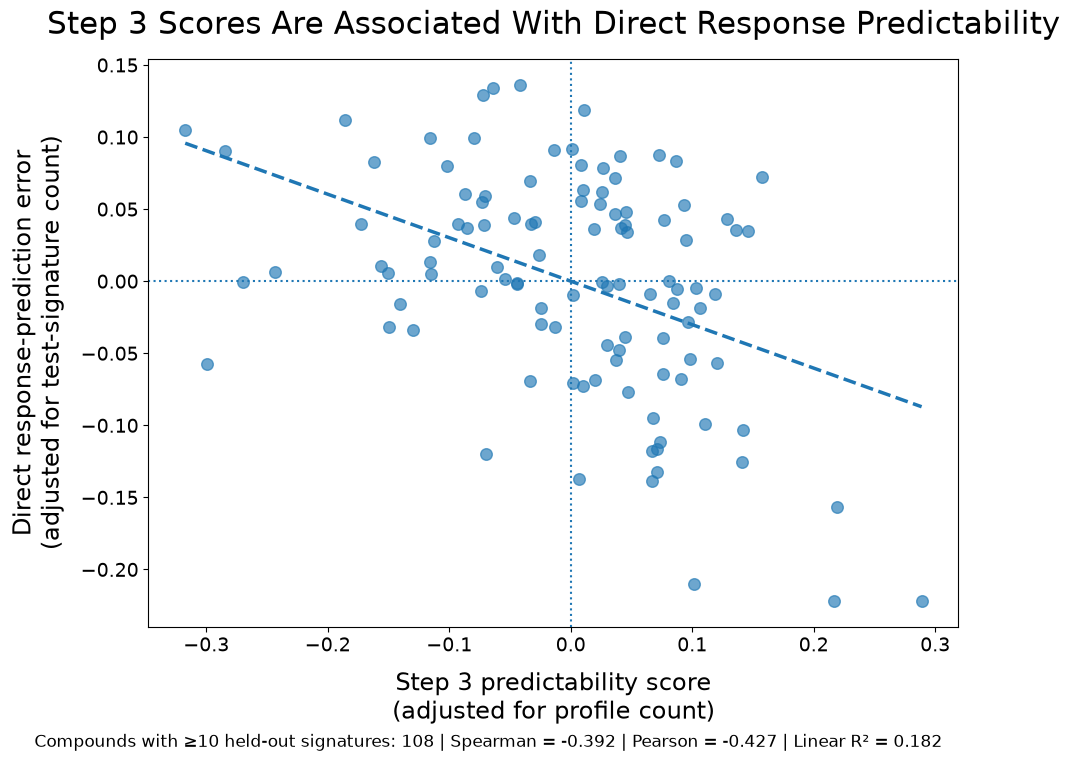


Saved figure:
/Users/mell/predicting-predictability/figures/step5_direct_response/step5_step3_vs_direct_mse_count_adjusted_n10.png

Saved figure metrics:
/Users/mell/predicting-predictability/data/step5_direct_response/step5_step3_vs_direct_mse_count_adjusted_n10_metrics.csv


,minimum_test_signatures,n_compounds,count_adjusted_spearman,spearman_pvalue,count_adjusted_pearson,pearson_pvalue,linear_r2
0,10,108,-0.391742,0.000028,-0.426872,0.000004,0.18222


In [16]:
# Visualize the count-adjusted relationship between
# Step 3 predictability and direct Step 5 prediction error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import r2_score



# Use compounds with at least 10 held-out signatures


MINIMUM_TEST_SIGNATURES = 10

plot_data = (
    score_comparison.loc[
        score_comparison["n_test_signatures"]
        >= MINIMUM_TEST_SIGNATURES
    ]
    .dropna(
        subset=[
            "source_normalized_inverted_score",
            "n_profiles",
            "mean_response_mse",
            "n_test_signatures",
        ]
    )
    .copy()
    .reset_index(drop=True)
)



# Remove each score's relationship with profile count


plot_data["step3_count_adjusted"] = (
    residualize_against_count(
        values=plot_data[
            "source_normalized_inverted_score"
        ],
        counts=plot_data["n_profiles"],
    )
)

plot_data["direct_mse_count_adjusted"] = (
    residualize_against_count(
        values=plot_data["mean_response_mse"],
        counts=plot_data["n_test_signatures"],
    )
)



# Calculate association metrics


adjusted_spearman_result = spearmanr(
    plot_data["step3_count_adjusted"],
    plot_data["direct_mse_count_adjusted"],
)

adjusted_spearman = (
    adjusted_spearman_result.correlation
)

adjusted_spearman_pvalue = (
    adjusted_spearman_result.pvalue
)

adjusted_pearson_result = pearsonr(
    plot_data["step3_count_adjusted"],
    plot_data["direct_mse_count_adjusted"],
)

adjusted_pearson = (
    adjusted_pearson_result.statistic
)

adjusted_pearson_pvalue = (
    adjusted_pearson_result.pvalue
)



# Fit a straight line and calculate linear R²


line_coefficients = np.polyfit(
    plot_data["step3_count_adjusted"],
    plot_data["direct_mse_count_adjusted"],
    deg=1,
)

fitted_y = np.polyval(
    line_coefficients,
    plot_data["step3_count_adjusted"],
)

adjusted_r2 = r2_score(
    plot_data["direct_mse_count_adjusted"],
    fitted_y,
)

line_x = np.linspace(
    plot_data["step3_count_adjusted"].min(),
    plot_data["step3_count_adjusted"].max(),
    200,
)

line_y = np.polyval(
    line_coefficients,
    line_x,
)



# Print metrics


print("Compounds:", len(plot_data))

print(
    "Count-adjusted Spearman:",
    round(adjusted_spearman, 3),
)

print(
    "Spearman p-value:",
    f"{adjusted_spearman_pvalue:.3e}",
)

print(
    "Count-adjusted Pearson:",
    round(adjusted_pearson, 3),
)

print(
    "Pearson p-value:",
    f"{adjusted_pearson_pvalue:.3e}",
)

print(
    "Linear R²:",
    round(adjusted_r2, 3),
)



# Create the figure


FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step5_direct_response"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

STEP3_STEP5_FIGURE_PATH = (
    FIG_DIR
    / "step5_step3_vs_direct_mse_count_adjusted_n10.png"
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

ax.scatter(
    plot_data["step3_count_adjusted"],
    plot_data["direct_mse_count_adjusted"],
    alpha=0.65,
    s=70,
)

ax.plot(
    line_x,
    line_y,
    linestyle="--",
    linewidth=2.5,
)

ax.axhline(
    0,
    linestyle=":",
    linewidth=1.5,
)

ax.axvline(
    0,
    linestyle=":",
    linewidth=1.5,
)

ax.set_title(
    "Step 3 Scores Are Associated With Direct Response Predictability",
    fontsize=22,
    pad=18,
)

ax.set_xlabel(
    "Step 3 predictability score\n"
    "(adjusted for profile count)",
    fontsize=17,
    labelpad=10,
)

ax.set_ylabel(
    "Direct response-prediction error\n"
    "(adjusted for test-signature count)",
    fontsize=17,
    labelpad=10,
)

ax.tick_params(
    axis="both",
    labelsize=14,
)

fig.text(
    0.5,
    0.02,
    (
        f"Compounds with ≥{MINIMUM_TEST_SIGNATURES} held-out signatures: "
        f"{len(plot_data)} | "
        f"Spearman = {adjusted_spearman:.3f} | "
        f"Pearson = {adjusted_pearson:.3f} | "
        f"Linear R² = {adjusted_r2:.3f}"
    ),
    ha="center",
    fontsize=12.5,
)

fig.subplots_adjust(
    left=0.16,
    right=0.97,
    top=0.88,
    bottom=0.17,
)

plt.savefig(
    STEP3_STEP5_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()



# Save figure metrics


figure_metrics = pd.DataFrame(
    [
        {
            "minimum_test_signatures":
                MINIMUM_TEST_SIGNATURES,
            "n_compounds":
                len(plot_data),
            "count_adjusted_spearman":
                adjusted_spearman,
            "spearman_pvalue":
                adjusted_spearman_pvalue,
            "count_adjusted_pearson":
                adjusted_pearson,
            "pearson_pvalue":
                adjusted_pearson_pvalue,
            "linear_r2":
                adjusted_r2,
        }
    ]
)

FIGURE_METRICS_PATH = (
    STEP5_DIR
    / "step5_step3_vs_direct_mse_count_adjusted_n10_metrics.csv"
)

figure_metrics.to_csv(
    FIGURE_METRICS_PATH,
    index=False,
)

print("\nSaved figure:")
print(STEP3_STEP5_FIGURE_PATH)

print("\nSaved figure metrics:")
print(FIGURE_METRICS_PATH)

display(figure_metrics)